In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

In [2]:
# 1. Load the dataset
# Ensure the CSV file 'heart_stacking.csv' is in your working directory
df = pd.read_csv('heart_stacking.csv')

# 2. Preprocess the data
# Using features specified: Cholesterol, Max Heart Rate, Age
X = df[['Cholesterol', 'MaxHeartRate', 'Age']]
y = df['HeartDisease']

In [3]:
# Split the data into Training and Testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define Base Models
base_models = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

In [4]:
# 4. Initialize and Train the Stacking Classifier
# The final_estimator combines the predictions of base_models
stack_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())
stack_model.fit(X_train, y_train)

# 5. Evaluate Individual Models vs. Stacking Classifier
model_results = {}

In [5]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
model_results['Logistic Regression'] = accuracy_score(y_test, lr.predict(X_test))

In [6]:
# SVM
svm = SVC()
svm.fit(X_train, y_train)
model_results['SVM'] = accuracy_score(y_test, svm.predict(X_test))

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
model_results['Decision Tree'] = accuracy_score(y_test, dt.predict(X_test))

In [7]:
# Stacking Classifier
model_results['Stacking Classifier'] = accuracy_score(y_test, stack_model.predict(X_test))

# Print Results
print("Model Accuracies:")
for model, acc in model_results.items():
    print(f"{model}: {acc:.4f}")

Model Accuracies:
Logistic Regression: 0.6250
SVM: 0.6250
Decision Tree: 0.7083
Stacking Classifier: 0.6667


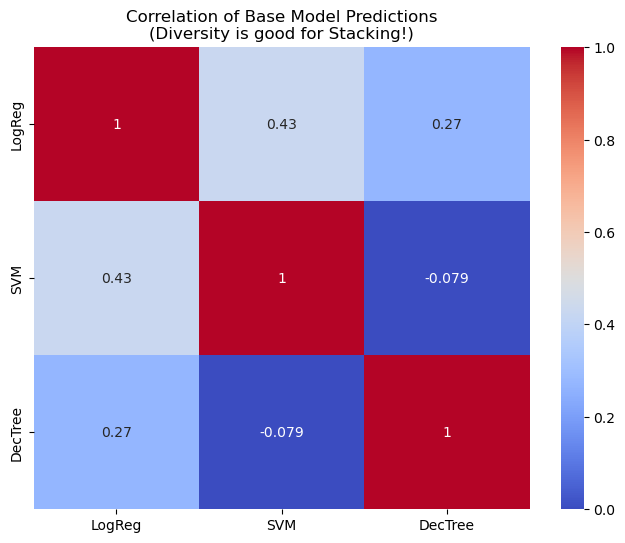

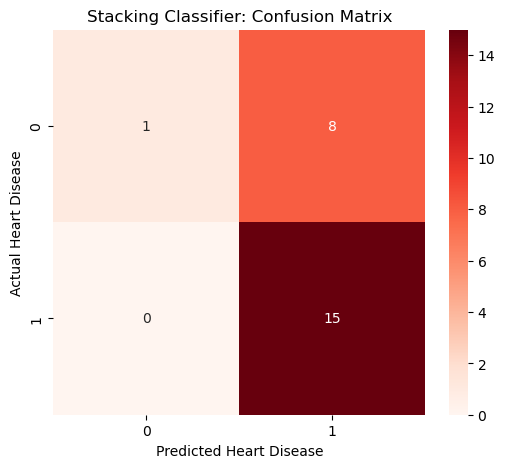

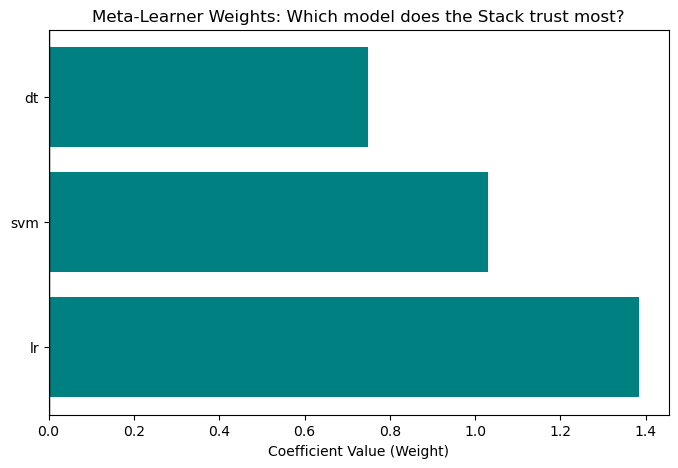

In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- 6. Advanced Stacking Visualizations ---

# A. Prediction Correlation Heatmap
# This shows how similar the base models' predictions are. 
# Stacking works best when models are NOT perfectly correlated!
base_preds = pd.DataFrame({
    'LogReg': lr.predict(X_test),
    'SVM': svm.predict(X_test),
    'DecTree': dt.predict(X_test)
})

plt.figure(figsize=(8, 6))
sns.heatmap(base_preds.corr(), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlation of Base Model Predictions\n(Diversity is good for Stacking!)')
plt.show()

# B. Confusion Matrix for the Stacking Classifier
plt.figure(figsize=(6, 5))
y_pred_stack = stack_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Stacking Classifier: Confusion Matrix')
plt.xlabel('Predicted Heart Disease')
plt.ylabel('Actual Heart Disease')
plt.show()

# C. Meta-Learner (Final Estimator) Importance
# Since your final_estimator is Logistic Regression, we can see the coefficients
meta_weights = stack_model.final_estimator_.coef_[0]
base_model_names = [name for name, _ in base_models]

plt.figure(figsize=(8, 5))
plt.barh(base_model_names, meta_weights, color='teal')
plt.axvline(0, color='black', lw=1)
plt.title('Meta-Learner Weights: Which model does the Stack trust most?')
plt.xlabel('Coefficient Value (Weight)')
plt.show()